<a href="https://colab.research.google.com/github/anuragN2107/High-Performance-Car-Resale-Analytics-Forecasting/blob/main/Car_Resale_Analysis_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Colab Link-https://colab.research.google.com/drive/1rBa1Cy6hxaSKaI5JULkOKrbEGiAcVWeR?usp=sharing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
df = pd.read_csv('/content/Car_Resale_Price.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [ ]:
#DataSet Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df.describe(include="object")

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [ ]:
# Data Cleaning and Preprocessing
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df



,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,petrol,dealer,manual,0,11
1,sx4,2013,4.75,9.54,43000,diesel,dealer,manual,0,12
2,ciaz,2017,7.25,9.85,6900,petrol,dealer,manual,0,8
3,wagon r,2011,2.85,4.15,5200,petrol,dealer,manual,0,14
4,swift,2014,4.60,6.87,42450,diesel,dealer,manual,0,11
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,diesel,dealer,manual,0,9
297,brio,2015,4.00,5.90,60000,petrol,dealer,manual,0,10
298,city,2009,3.35,11.00,87934,petrol,dealer,manual,0,16
299,city,2017,11.50,12.50,9000,diesel,dealer,manual,0,8


In [ ]:
# Add new column: Age of car
current_year = 2025
df['Car_Age'] = current_year - df['Year']

In [ ]:
df.rename(columns={
    'Car_Name': 'Brand',
    'Present_Price': 'Price'
}, inplace=True)

In [ ]:
# Classify price segments using NumPy
price_array = df['Price'].values # Corrected column name to 'price'
price_segment = np.where(price_array > 2000000, 'Luxury', 'Standard')
df['Segment'] = price_segment

In [ ]:
df.head()

,Brand,Year,Selling_Price,Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age,Car_Age,Segment
0,ritz,2014,3.35,5.59,27000,petrol,dealer,manual,0,11,11,Standard
1,sx4,2013,4.75,9.54,43000,diesel,dealer,manual,0,12,12,Standard
2,ciaz,2017,7.25,9.85,6900,petrol,dealer,manual,0,8,8,Standard
3,wagon r,2011,2.85,4.15,5200,petrol,dealer,manual,0,14,14,Standard
4,swift,2014,4.60,6.87,42450,diesel,dealer,manual,0,11,11,Standard


In [ ]:
# Display summary statistics of the dataset
print("\nSummary of Descriptive Statistics:")
print(df.describe())

# Rename columns for clarity
df.rename(columns={
    'Car_Name': 'Brand',
    'Present_Price': 'Price'
}, inplace=True)

# Calculate and display the mean price grouped by car brand
print("\nMean Price Grouped by Brand:")
average_price_by_brand = df.groupby('Brand')['Price'].mean()
print(average_price_by_brand)



Summary of Descriptive Statistics:
              Year  Selling_Price       Price     Kms_Driven       Owner  \
count   299.000000     299.000000  299.000000     299.000000  299.000000   
mean   2013.615385       4.589632    7.541037   36916.752508    0.043478   
std       2.896868       4.984240    8.567887   39015.170352    0.248720   
min    2003.000000       0.100000    0.320000     500.000000    0.000000   
25%    2012.000000       0.850000    1.200000   15000.000000    0.000000   
50%    2014.000000       3.510000    6.100000   32000.000000    0.000000   
75%    2016.000000       6.000000    9.840000   48883.500000    0.000000   
max    2018.000000      35.000000   92.600000  500000.000000    3.000000   

              Age     Car_Age  
count  299.000000  299.000000  
mean    11.384615   11.384615  
std      2.896868    2.896868  
min      7.000000    7.000000  
25%      9.000000    9.000000  
50%     11.000000   11.000000  
75%     13.000000   13.000000  
max     22.000000   22.

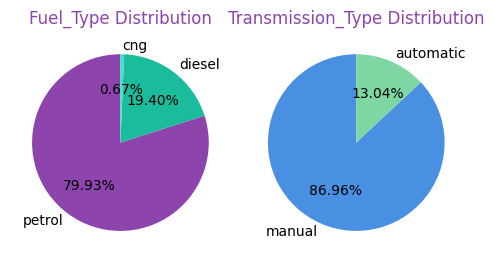

In [ ]:
# Importing necessary liabrary
import matplotlib.pyplot as plt

# Creating subplots
fig, axs = plt.subplots(1,2, figsize=(5, 5))

# First Pie Chart - Fuel Type
Fuel_Type_Count = df['Fuel_Type'].value_counts()
axs[0].pie(x=Fuel_Type_Count, labels=Fuel_Type_Count.index, autopct='%1.2f%%', colors = ["#8e44ad", "#1abc9c", "#40e0d0"], startangle=90)
axs[0].set_title("Fuel_Type Distribution", color="#8e44ad")

# Second Pie Chart - Transmission
Transmission_Count = df['Transmission'].value_counts()
axs[1].pie(x=Transmission_Count, labels=Transmission_Count.index, autopct='%1.2f%%', colors = ["#4a90e2", "#7ed6a3", "#f7a35c"], startangle=90)
axs[1].set_title("Transmission_Type Distribution", color="#8e44ad")

plt.tight_layout()
plt.show()


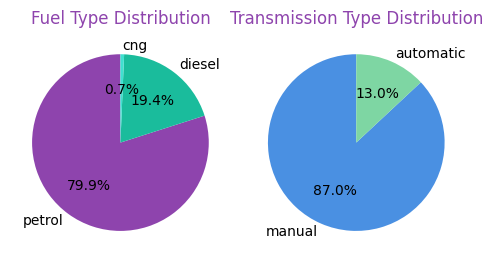

In [ ]:
# Importing necessary library
import matplotlib.pyplot as plt

# Creating subplots (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(5, 5))  # Wider figure for clarity

# First Pie Chart - Fuel Type
fuel_type_count = df['Fuel_Type'].value_counts()
axs[0].pie(
    fuel_type_count,
    labels=fuel_type_count.index,
    autopct='%1.1f%%',
    colors=["#8e44ad", "#1abc9c", "#40e0d0"],
    startangle=90
)
axs[0].set_title("Fuel Type Distribution", color="#8e44ad", fontsize=12)

# Second Pie Chart - Transmission Type
transmission_count = df['Transmission'].value_counts()
axs[1].pie(
    transmission_count,
    labels=transmission_count.index,
    autopct='%1.1f%%',
    colors=["#4a90e2", "#7ed6a3", "#f7a35c"],
    startangle=90
)
axs[1].set_title("Transmission Type Distribution", color="#8e44ad", fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()


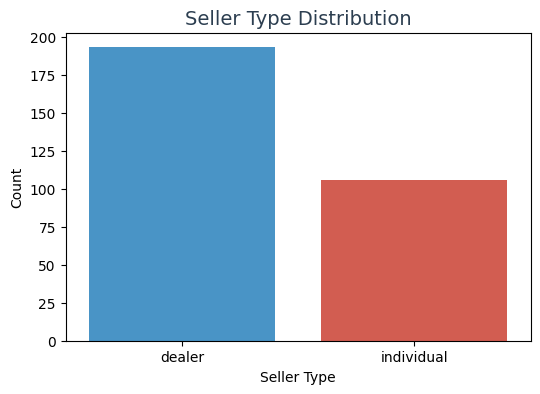

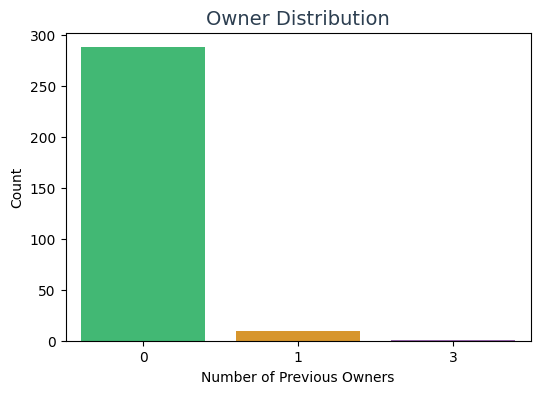

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count Plot for Seller_Type
plt.figure(figsize=(6,4))
sns.countplot(
    x='Seller_Type',
    hue='Seller_Type',
    data=df,
    palette=['#3498db', '#e74c3c'],  # Blue for Dealer, Red for Individual
    legend=False
)
plt.title("Seller Type Distribution", fontsize=14, color="#2c3e50")
plt.xlabel("Seller Type")
plt.ylabel("Count")
plt.show()

# Count Plot for Owner
owner_colors = sns.color_palette(['#2ecc71', '#f39c12', '#9b59b6'])  # Green, Orange, Purple

plt.figure(figsize=(6,4))
sns.countplot(
    x='Owner',
    hue='Owner',
    data=df,
    palette=owner_colors,
    legend=False
)
plt.title("Owner Distribution", fontsize=14, color="#2c3e50")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Count")
plt.show()


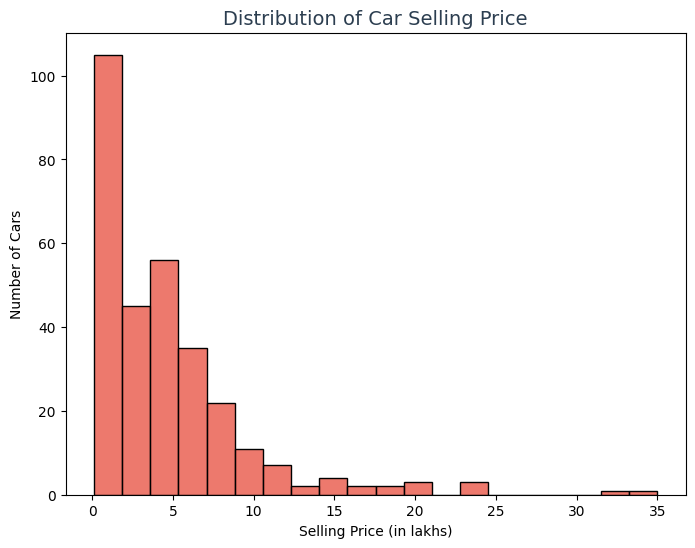

In [ ]:
# Histogram of car prices
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.histplot(df['Selling_Price'], bins=20, kde=False, color="#e74c3c")
plt.title("Distribution of Car Selling Price", fontsize=14, color="#2c3e50")
plt.xlabel("Selling Price (in lakhs)")
plt.ylabel("Number of Cars")
plt.show()

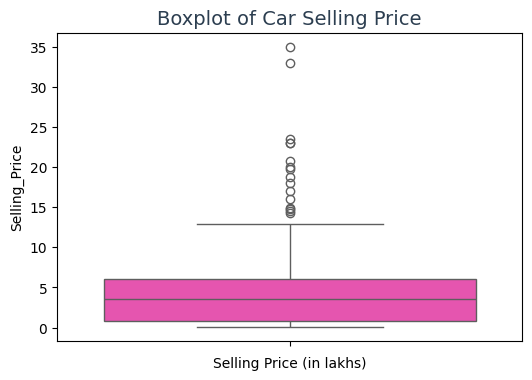

In [ ]:
#Boxplot for Selling Price
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Selling_Price'], color="#FD3DB5")
plt.title("Boxplot of Car Selling Price", fontsize=14, color="#2c3e50")
plt.xlabel("Selling Price (in lakhs)")
plt.show()


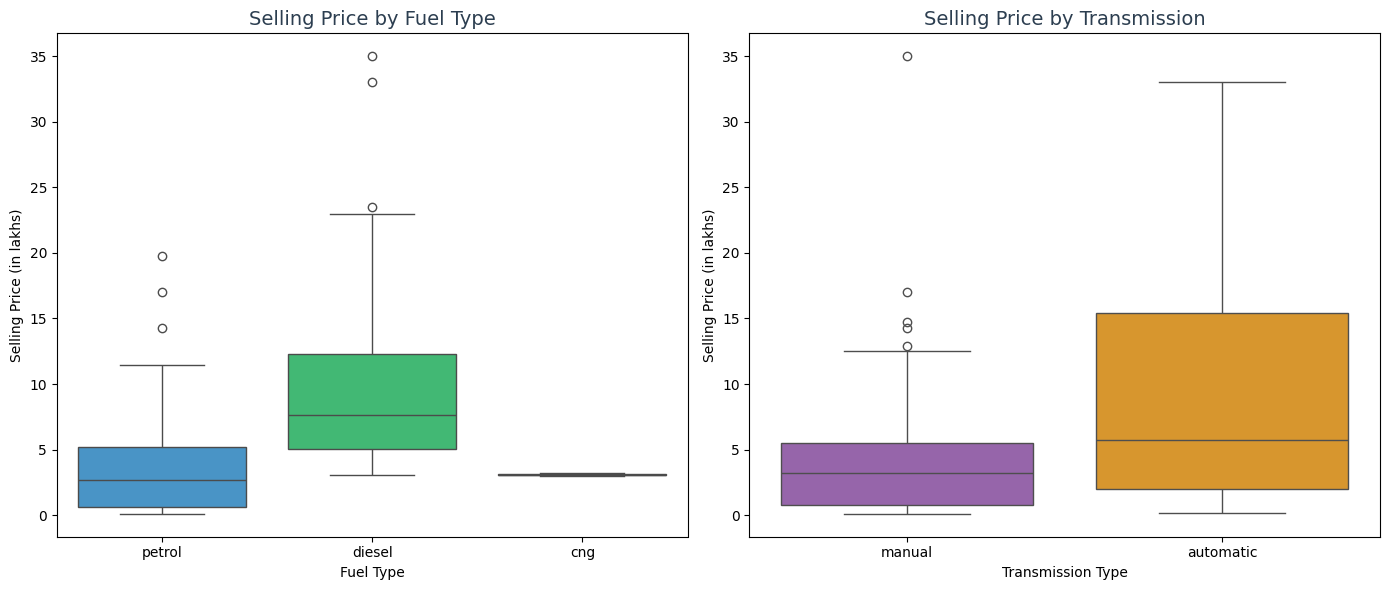

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14,6))

# Boxplot by Fuel Type
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette=['#3498db', '#2ecc71', '#e74c3c'], ax=axs[0], hue='Fuel_Type', legend=False)
axs[0].set_title("Selling Price by Fuel Type", fontsize=14, color="#2c3e50")
axs[0].set_xlabel("Fuel Type")
axs[0].set_ylabel("Selling Price (in lakhs)")

# Boxplot by Transmission
sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette=['#9b59b6', '#f39c12'], ax=axs[1], hue='Transmission', legend=False)
axs[1].set_title("Selling Price by Transmission", fontsize=14, color="#2c3e50")
axs[1].set_xlabel("Transmission Type")
axs[1].set_ylabel("Selling Price (in lakhs)")

# Adjust layout
plt.tight_layout()
plt.show()

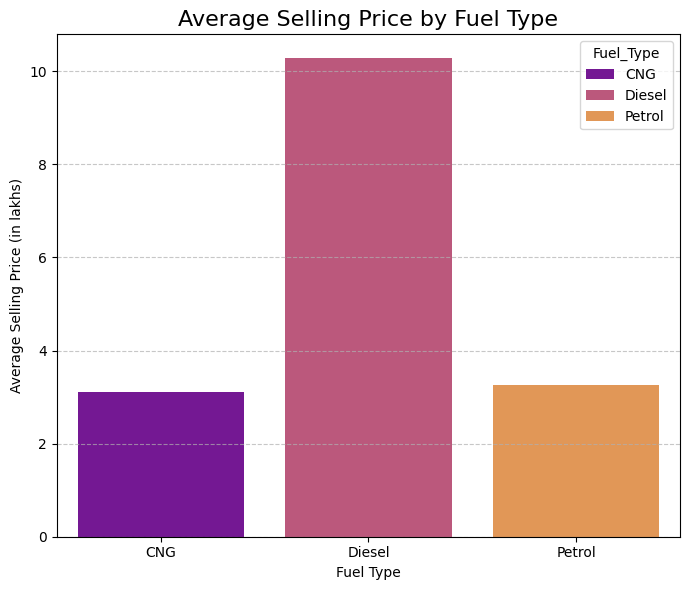

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Calculate the average selling price for each fuel type
average_selling_price_by_fuel = df.groupby('Fuel_Type')['Selling_Price'].mean().reset_index()
# Create the bar plot
plt.figure(figsize=(7, 6))
sns.barplot(x='Fuel_Type', y='Selling_Price', data=average_selling_price_by_fuel, palette='plasma', hue='Fuel_Type', legend=True)
plt.title('Average Selling Price by Fuel Type', fontsize=16)
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price (in lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

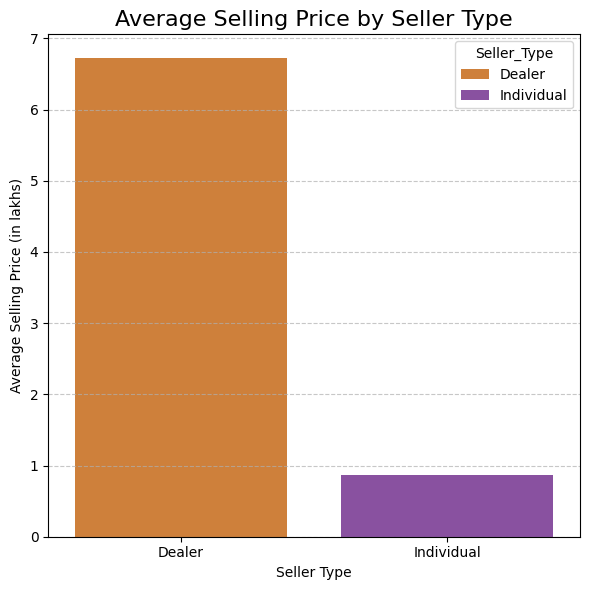

In [ ]:
#BarPlot:Average Selling Price by Seller Type
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Calculate the average selling price for each seller type
avg_price_by_seller = df.groupby('Seller_Type')['Selling_Price'].mean().reset_index()
# Create the bar plot
plt.figure(figsize=(6, 6))
sns.barplot(x='Seller_Type', y='Selling_Price', data=avg_price_by_seller, palette=['#e67e22', '#8e44ad'], hue='Seller_Type', legend=True)
plt.title('Average Selling Price by Seller Type', fontsize=16)
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price (in lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

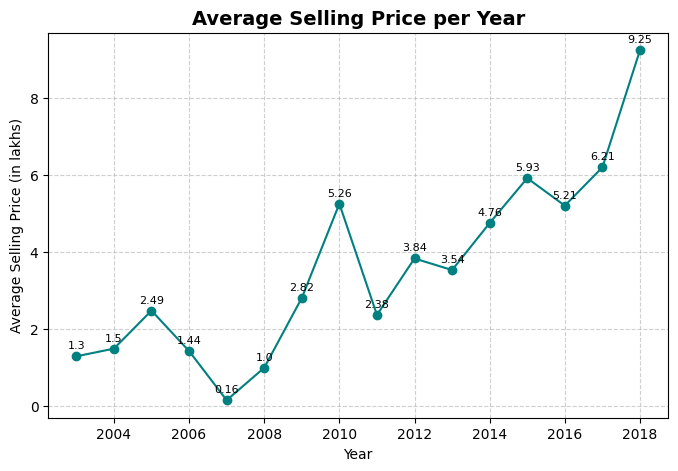

In [ ]:
#line plot:Average selling price per year
import pandas as pd
import matplotlib.pyplot as plt
# Group by Year and calculate average Selling Price
avg_price_per_year = df.groupby('Year')['Selling_Price'].mean().reset_index()
# Plot line chart
plt.figure(figsize=(8,5))
plt.plot(avg_price_per_year['Year'], avg_price_per_year['Selling_Price'],
         marker='o', linestyle='-', color='teal')
# Add labels on each data point
for i, row in avg_price_per_year.iterrows():
    plt.text(row['Year'], row['Selling_Price']+0.2, round(row['Selling_Price'],2),
             ha='center', fontsize=8)
# Add title and axis labels
plt.title('Average Selling Price per Year', fontsize=14, weight='bold')
plt.xlabel('Year')
plt.ylabel('Average Selling Price (in lakhs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


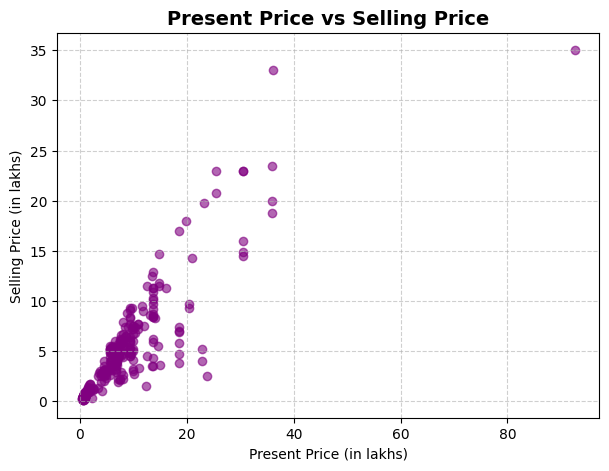

In [ ]:
#Scatter plot: Present Price Vs Selling Price
import pandas as pd
import matplotlib.pyplot as plt
# Scatter plot
plt.figure(figsize=(7,5))
plt.scatter(df['Present_Price'], df['Selling_Price'], alpha=0.6, color='purple')
# Labels and title
plt.title('Present Price vs Selling Price', fontsize=14, weight='bold')
plt.xlabel('Present Price (in lakhs)')
plt.ylabel('Selling Price (in lakhs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

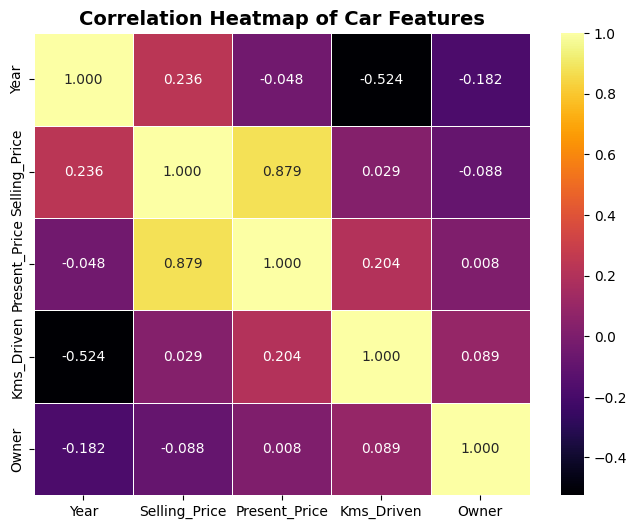

In [ ]:
#Heatmap:Correlation Heatmap of car's Feature
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Select only numerical columns for correlation
numeric_df = df.select_dtypes(include=['float64','int64'])
# Compute correlation matrix
corr = numeric_df.corr()
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='inferno', fmt=".3f", linewidths=0.5)
plt.title('Correlation Heatmap of Car Features', fontsize=14, weight='bold')
plt.show()


In [ ]:
#OOPs Implementation
import pandas as pd
# Displaying available car options.
print("Available Car options")
print(df['Car_Name'].unique())

print("\nAvailable Years of Production")
print(df['Year'].unique())

class Car:
    def __init__(self, row):
        self.Car_Name = row['Car_Name']
        self.Year = row["Year"]
        self.Selling_Price = row["Selling_Price"]
        self.Present_Price = row["Present_Price"]
        self.Kms_Driven = row["Kms_Driven"]
        self.Fuel_Type = row["Fuel_Type"]
        self.Seller_Type = row["Seller_Type"]
        self.Transmission = row["Transmission"]
        self.Owner = row["Owner"]

    def get_info(self):
        print(f"Car Name: {self.Car_Name}")
        print(f"Year: {self.Year}")
        print(f"Selling Price: {self.Selling_Price}")
        print(f"Present_Price: {self.Present_Price}")
        print(f"Kms_Driven: {self.Kms_Driven}")
        print(f"Fuel_Type: {self.Fuel_Type}")
        print(f"Seller_Type: {self.Seller_Type}")
        print(f"Transmission: {self.Transmission}")
        print(f"Owner: {self.Owner}")

class Profitable_car(Car):
    def __init__(self, row):
        super().__init__(row)

    def is_profitable(self):
        if self.Selling_Price < self.Present_Price * 0.75:
            print("The car is profitable.")
        else:
            print("The car is not profitable.")

def Search_Car(Car_Name, Year):
    result = df[(df["Car_Name"].str.lower() == Car_Name.lower()) & (df["Year"] == Year)]
    if not result.empty:
        for index, row in result.iterrows():
            car = Profitable_car(row)
            car.get_info()
            car.is_profitable()
            print("-" * 40)
    else:
        print("Car not found")

name = input("Enter the car name: ")
year = int(input("Enter the year of Manufacture: "))
Search_Car(name, year)

Available Car options
['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Avenger St